# Week 1: Engineering Exploratory Data Analysis

Project: Culvert Exceedance Risk Assessment
Author: Brice Nelson, PE, MBA
Notebook: 01_eda.ipynb
Week 1: Engineering Exploratory Data Analysis

In [1]:
# This notebook is designed to demonstrate the process of exploratory data analysis for the Culvert Exceedance Risk Assessment project. The goal is to understand the data, identify patterns, and prepare it for further analysis.

# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project Root Directory
PROJECT_ROOT = Path.cwd().parents[2]

# Data directory
DATA_DIR = PROJECT_ROOT / "data/raw/engineering/week_01"

# File Name
FILE_NAME = "annual_peak_flows_dirty.csv"

# File Path
FILE_PATH = DATA_DIR / FILE_NAME

print(f"Working directory: {Path.cwd()}")
print(f"Project root:      {PROJECT_ROOT}")
print(f"Reading file:      {FILE_PATH}")
print(f"File exists:       {FILE_PATH.exists()}")

Working directory: /home/brice-nelson/Documents/computerScience/PROJECTS/brice_dev_lab/monte_carlo_drills/notebooks/engineering/week_01
Project root:      /home/brice-nelson/Documents/computerScience/PROJECTS/brice_dev_lab/monte_carlo_drills
Reading file:      /home/brice-nelson/Documents/computerScience/PROJECTS/brice_dev_lab/monte_carlo_drills/data/raw/engineering/week_01/annual_peak_flows_dirty.csv
File exists:       True


In [2]:
# Load the data
try:
    df = pd.read_csv(FILE_PATH)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"File not found: {FILE_PATH}")

Data loaded successfully.


In [3]:
# Display the first few rows of the dataframe
df.head(5)

,Water Year,Peak Flow,Units,Status
0,2007,217.7,cfs,Final
1,2005,398.3,cfs,Final
2,2006,130.6,cfs,Final
3,2016,502.4,cfs,Final
4,2023,429.2,cfs,Final


In [4]:
# Check shape of the dataframe
print(f"Dataframe shape: {df.shape}")

Dataframe shape: (31, 4)


| EDA section | What to include | Question it answers |
|---|---|---|
| Record coverage | Year range, missing years, record status | How complete is the record? |
| Annual peak-flow plot | Flows sorted by water year; identify unusually high and low years | Are there apparent shifts, clusters, or trends? |
| Distribution | Histogram and boxplot | Are flows skewed? Are extreme observations prominent? |
| Variability | Standard deviation, interquartile range, coefficient of variation, skewness | How variable are flows relative to their typical magnitude? |
| Empirical distribution | ECDF and selected percentiles | What fraction of recorded annual peaks falls below a given flow? |
| Extreme-flow review | Highest five observations with their years | Which events drive the upper end of the record? |
| Modeling implications | Written interpretation and limitations | What should the next modeling notebook investigate? |

# Notebook Sequence

1. Purpose and questions. State that you’re exploring annual peak flows to inform culvert exceedance modeling.
2. Load the same cleaned CSV. Keep cleaning in your ingestion workflow; document any new issues discovered here.
3. Check coverage and sort by year.
4. Plot annual peaks over time. Discuss visible patterns without treating an apparent trend as established evidence.
5. Plot the histogram and boxplot. With 28 observations, histogram shape depends noticeably on the bin choices.
6. Calculate variability and selected percentiles. Label percentiles as sample percentiles.
7. Plot the ECDF. This shows the observed distribution without assuming a particular probability distribution.
8. Review the largest flows. A boxplot flag is a reason to investigate an observation, not delete it.
9. Write findings and modeling implications.

In [6]:
df.columns

Index(['Water Year', 'Peak Flow', 'Units', 'Status'], dtype='str')

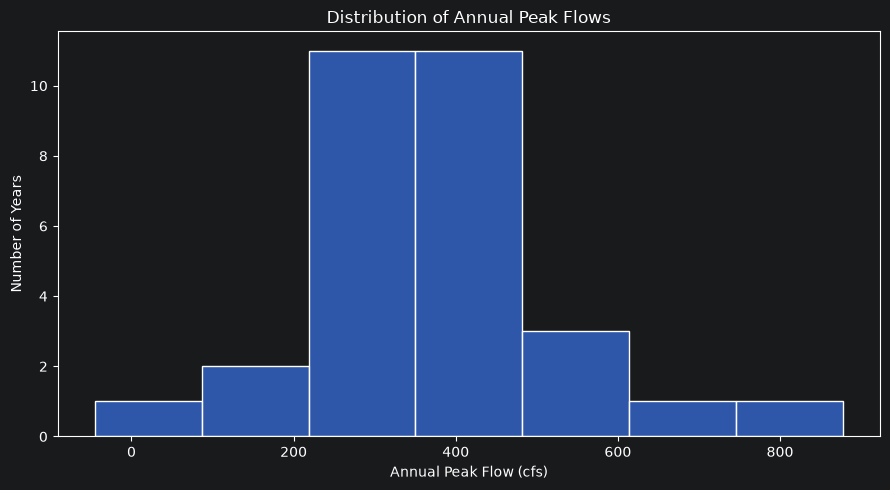

In [7]:
# Plot the annual peak flows distribution
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Peak Flow",
    bins=7,
    edgecolor="white",
    ax=ax,
)

ax.set(
    title="Distribution of Annual Peak Flows",
    xlabel="Annual Peak Flow (cfs)",
    ylabel="Number of Years",
)

plt.tight_layout()
plt.show()

In [8]:
df["Peak Flow"].rename("peak_flow").describe().to_frame()

,peak_flow
count,30.000000
mean,365.963333
std,165.898289
min,-45.000000
25%,261.500000
50%,379.800000
75%,441.875000
max,877.200000


In [12]:
df = df.rename(columns={"Peak Flow": "peak_flow"})
print(df.columns)

Index(['Water Year', 'peak_flow', 'Units', 'Status'], dtype='str')


In [13]:
flows = df["peak_flow"].dropna().to_numpy(dtype=float)

if not np.isfinite(flows).all() or (flows <= 0).any():
    raise ValueError("Lognormal modeling requires finite, positive flows.")

log_flows = np.log(flows)

mu_log = log_flows.mean()
sigma_log = log_flows.std(ddof=1)

print(f"Log-space mean: {mu_log:.4f}")
print(f"Log-space standard deviation: {sigma_log:.4f}")

ValueError: Lognormal modeling requires finite, positive flows.

In [15]:
df.columns

Index(['Water Year', 'peak_flow', 'Units', 'Status'], dtype='str')

In [16]:
df = df.rename(columns={"Water Year": "water_year"})
print(df.columns)

Index(['water_year', 'peak_flow', 'Units', 'Status'], dtype='str')


In [17]:
df.loc[df["peak_flow"] <= 0, ["water_year", "peak_flow"]]


,water_year,peak_flow
23,2019,-45.0


In [19]:
# drop rows with non-positive peak flows
df = df[df["peak_flow"] > 0].reset_index(drop=True)

In [20]:
flows = df["peak_flow"].dropna().to_numpy(dtype=float)

if not np.isfinite(flows).all() or (flows <= 0).any():
    raise ValueError("Lognormal modeling requires finite, positive flows.")

log_flows = np.log(flows)

mu_log = log_flows.mean()
sigma_log = log_flows.std(ddof=1)

print(f"Log-space mean: {mu_log:.4f}")
print(f"Log-space standard deviation: {sigma_log:.4f}")

Log-space mean: 5.8710
Log-space standard deviation: 0.3822


In [21]:
# Simulate monte carlo samples from the fitted lognormal distribution

rng = np.random.default_rng(seed=42)
n_simulations = 10_000

simulated_flows = rng.lognormal(
    mean=mu_log,
    sigma=sigma_log,
    size=n_simulations,
)

pd.Series(simulated_flows, name="simulated_peak_flow_cfs").describe()

count    10000.000000
mean       380.319294
std        152.082160
min         66.246973
25%        273.715214
50%        352.806009
75%        454.580991
max       1651.863499
Name: simulated_peak_flow_cfs, dtype: float64

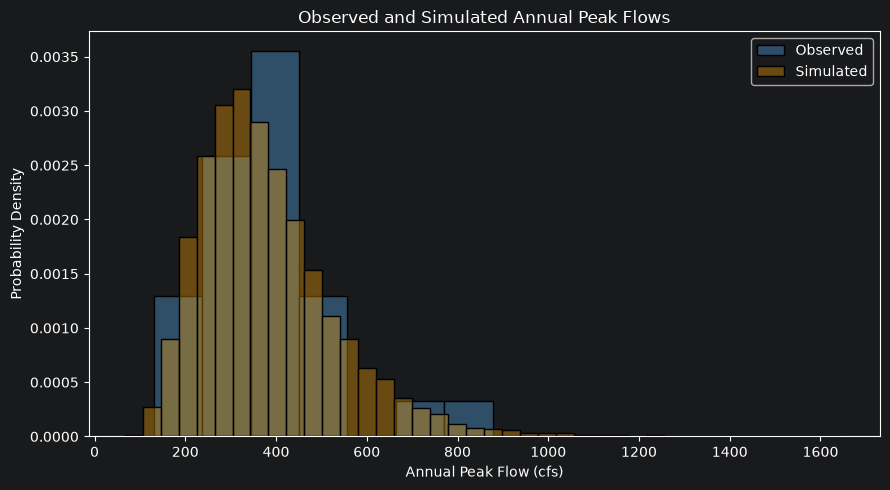

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    flows,
    bins=7,
    stat="density",
    color="steelblue",
    alpha=0.5,
    label="Observed",
    ax=ax,
)

sns.histplot(
    simulated_flows,
    bins=40,
    stat="density",
    color="orange",
    alpha=0.35,
    label="Simulated",
    ax=ax,
)

ax.set(
    title="Observed and Simulated Annual Peak Flows",
    xlabel="Annual Peak Flow (cfs)",
    ylabel="Probability Density",
)
ax.legend()

plt.tight_layout()
plt.show()

In [23]:
# Calculate the exceedance probability for a given flow threshold
capacity_cfs = 600.0  # Example only—replace with project capacity

exceeds_capacity = simulated_flows > capacity_cfs
annual_exceedance_probability = exceeds_capacity.mean()

observed_exceedance_fraction = (flows > capacity_cfs).mean()

print(f"Capacity: {capacity_cfs:,.1f} cfs")
print(f"Simulated exceedances: {exceeds_capacity.sum():,}")
print(
    "Modeled annual exceedance probability: "
    f"{annual_exceedance_probability:.2%}"
)
print(
    "Observed fraction of years exceeding capacity: "
    f"{observed_exceedance_fraction:.2%}"
)

Capacity: 600.0 cfs
Simulated exceedances: 856
Modeled annual exceedance probability: 8.56%
Observed fraction of years exceeding capacity: 6.90%
